In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/data_raw.csv")

In [3]:
df

,Unnamed: 0,client_id,dt,event_type
0,0,6095092,2024-06-20,clicks
1,1,541138559,2024-06-18,clicks
2,2,12189072,2024-06-20,clicks
3,3,674385020,2024-06-20,clicks
4,4,726939378,2024-06-20,clicks
...,...,...,...,...
27756043,27756043,819589730,2024-06-21,views
27756044,27756044,680187923,2024-06-20,views
27756045,27756045,519794764,2024-06-20,views
27756046,27756046,898541720,2024-06-21,views


In [4]:
unique_values = df['dt'].unique()
print(unique_values)

['2024-06-20' '2024-06-18' '2024-06-19' '2024-06-21' '2024-06-17']


In [5]:
# Преобразование данных в воронку (агрегация по client_id и dt)
funnel = df.pivot_table(
    index=['dt', 'client_id'],
    columns='event_type',
    values='Unnamed: 0',  # любая колонка для подсчета
    aggfunc='count',
    fill_value=0
).reset_index()

# Переименование колонок для удобства
funnel.columns.name = None
funnel = funnel.rename(columns={'view': 'views', 'click': 'clicks', 'add': 'adds'})

# Если нужны только view, click, add (на случай других событий)
required_cols = ['views', 'clicks', 'adds']
for col in required_cols:
    if col not in funnel.columns:
        funnel[col] = 0

# Теперь funnel содержит колонки: dt, client_id, views, clicks, adds

# 1. Расчет общего CTR (по всем данным)
total_clicks = funnel['clicks'].sum()
total_views = funnel['views'].sum()
ctr = total_clicks / total_views if total_views > 0 else 0

# 2. Дисперсия CTR через дельта-метод
# Дельта-метод: Var(p) ≈ p(1-p)/n, где p = CTR, n = количество просмотров
var_ctr = (ctr * (1 - ctr)) / total_views if total_views > 0 else 0

# 3. Среднее добавлений на пользователя
# Сначала агрегируем по пользователям
user_stats = funnel.groupby('client_id').agg({
    'adds': 'sum',
    'views': 'sum',
    'clicks': 'sum'
}).reset_index()

# Среднее добавлений на пользователя
mean_adds_per_user = user_stats['adds'].mean()

# Дисперсия среднего добавлений на пользователя
# Var(среднего) = Var(X)/n, где X - количество добавлений на пользователя
var_adds = user_stats['adds'].var() / len(user_stats) if len(user_stats) > 1 else 0

print("Результаты анализа:")
print("=" * 40)
print(f"Общий CTR: {ctr:.4f} ({ctr*100:.2f}%)")
print(f"Дисперсия CTR (дельта-метод): {var_ctr:.6f}")
print(f"Среднее добавлений на пользователя: {mean_adds_per_user:.4f}")
print(f"Дисперсия среднего добавлений: {var_adds:.6f}")
print("\nАгрегированные данные (первые 5 строк):")
print(funnel.head())

# Дополнительно: если нужна дисперсия CTR через биномиальное распределение
# Альтернативный метод - учитывающий, что каждый view имеет вероятность CTR
print("\n" + "=" * 40)
print("Альтернативный расчет дисперсии CTR (биномиальный):")
# Более точная формула: Var(CTR) = CTR*(1-CTR)/views
# Это то же самое, что и дельта-метод для пропорции
print(f"Дисперсия CTR (биномиальная): {var_ctr:.6f}")

# Сохранение обработанных данных
funnel.to_csv('data_processed.csv', index=False)
print("\nОбработанные данные сохранены в data_processed.csv")

Результаты анализа:
Общий CTR: 0.0198 (1.98%)
Дисперсия CTR (дельта-метод): 0.000000
Среднее добавлений на пользователя: 0.0689
Дисперсия среднего добавлений: 0.000000

Агрегированные данные (первые 5 строк):
           dt  client_id  adds  clicks  views
0  2024-06-17          1     0       0      3
1  2024-06-17          3     0       1      1
2  2024-06-17         19     0       0      3
3  2024-06-17         37     0       0      3
4  2024-06-17         41     0       0      1

Альтернативный расчет дисперсии CTR (биномиальный):
Дисперсия CTR (биномиальная): 0.000000

Обработанные данные сохранены в data_processed.csv


In [6]:
# --- 1. Загружаем данные (уже в формате воронки) ---
df = pd.read_csv('data_processed.csv')
print(f"✅ Загружено {len(df)} строк. Данные уже в формате воронки.")

# --- 2. Агрегируем по пользователям (client_id) за ВЕСЬ период ---
# Суммируем все просмотры, клики и добавления для каждого пользователя
user_agg = df.groupby('client_id', as_index=False).agg({
    'views': 'sum',
    'clicks': 'sum',
    'adds': 'sum'
})
print(f"✅ Агрегировано {len(user_agg)} уникальных пользователей.")

# --- 3. Рассчитываем метрики для КАЖДОГО пользователя ---
# Важно: избегаем деления на 0
user_agg['ctr'] = user_agg.apply(lambda row: row['clicks'] / row['views'] if row['views'] > 0 else 0, axis=1)
user_agg['cr_add'] = user_agg.apply(lambda row: row['adds'] / row['clicks'] if row['clicks'] > 0 else 0, axis=1)

print(f"\n📊 Основные статистики после агрегации:")
print(f"Средний CTR на пользователя: {user_agg['ctr'].mean():.4%}")
print(f"Средняя конверсия в добавление на пользователя: {user_agg['cr_add'].mean():.4%}")
print(f"Среднее добавлений на пользователя (глобальное): {user_agg['adds'].mean():.4f}")

# --- 4. Функция для расчёта дисперсии ratio-метрики (дельта-метод) ---
def var_ratio(x, y):
    """
    Расчёт дисперсии для отношения X/Y (например, клики/просмотры) по дельта-методу.
    x, y - массивы значений для каждого пользователя.
    """
    # Отфильтровываем случаи, где y=0, чтобы не было ошибок
    mask = (y > 0)
    x = x[mask]
    y = y[mask]

    if len(x) == 0:
        return 0.0

    mean_x = np.mean(x)
    mean_y = np.mean(y)
    var_x = np.var(x, ddof=1)
    var_y = np.var(y, ddof=1)
    cov_xy = np.cov(x, y, ddof=1)[0, 1]
    var = (var_x / mean_y**2) + (var_y * mean_x**2 / mean_y**4) - (2 * mean_x * cov_xy / mean_y**3)
    return var

# --- 5. Рассчитываем дисперсии для CTR и CR ---
# Для CTR: x = клики, y = просмотры (только у пользователей с views > 0)
var_ctr = var_ratio(user_agg['clicks'], user_agg['views'])
# Для конверсии в добавление: x = добавления, y = клики (только у пользователей с clicks > 0)
var_cr = var_ratio(user_agg['adds'], user_agg['clicks'])

print(f"\n🎯 РЕЗУЛЬТАТЫ ДЛЯ РАСЧЁТА MDE И РАЗМЕРА ВЫБОРКИ:")
print(f"Среднее значение CTR: {user_agg['ctr'].mean():.6f} ({user_agg['ctr'].mean():.4%})")
print(f"Дисперсия CTR (дельта-метод): {var_ctr:.10f}")
print(f"Стандартное отклонение CTR: {np.sqrt(var_ctr):.6f}")
print("-" * 50)
print(f"Среднее значение конверсии в добавление: {user_agg['cr_add'].mean():.6f} ({user_agg['cr_add'].mean():.4%})")
print(f"Дисперсия конверсии (дельта-метод): {var_cr:.10f}")
print(f"Стандартное отклонение конверсии: {np.sqrt(var_cr):.6f}")

# --- 6. Сохраняем финальную агрегацию ---
user_agg.to_csv('user_aggregated_final.csv', index=False)
print(f"\n💾 Финальные агрегированные данные сохранены в 'user_aggregated_final.csv'")

✅ Загружено 8278629 строк. Данные уже в формате воронки.
✅ Агрегировано 3102736 уникальных пользователей.

📊 Основные статистики после агрегации:
Средний CTR на пользователя: 1.1230%
Средняя конверсия в добавление на пользователя: 3.7820%
Среднее добавлений на пользователя (глобальное): 0.0689

🎯 РЕЗУЛЬТАТЫ ДЛЯ РАСЧЁТА MDE И РАЗМЕРА ВЫБОРКИ:
Среднее значение CTR: 0.011230 (1.1230%)
Дисперсия CTR (дельта-метод): 0.0084144573
Стандартное отклонение CTR: 0.091730
--------------------------------------------------
Среднее значение конверсии в добавление: 0.037820 (3.7820%)
Дисперсия конверсии (дельта-метод): 0.5454286140
Стандартное отклонение конверсии: 0.738531

💾 Финальные агрегированные данные сохранены в 'user_aggregated_final.csv'


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Загружаем данные из final_results_to_analyze.xlsx
# Предполагается, что файл находится в той же директории
try:
    df_results = pd.read_excel('/content/drive/MyDrive/final_results_to_analyze.xlsx')
    print("✅ Данные успешно загружены")
except FileNotFoundError:
    print("❌ Файл 'final_results_to_analyze.xlsx' не найден")
    # Создадим демонстрационные данные для примера
    np.random.seed(42)
    n_users = 50000
    dates = pd.date_range('2020-11-30', '2020-12-06')

    data = []
    for date in dates:
        for user_id in range(n_users // 7):
            ab_group = np.random.choice(['control', 'test'], p=[0.5, 0.5])

            # Симулируем данные с эффектом для тестовой группы
            if ab_group == 'control':
                view_prob = 0.3
                click_prob = 0.07
                add_prob = 0.027
                order_prob = 0.009
                sum_multiplier = 1.0
            else:
                view_prob = 0.32  # +6.7%
                click_prob = 0.08  # +14.3%
                add_prob = 0.028  # +3.7%
                order_prob = 0.0095  # +5.6%
                sum_multiplier = 1.15

            is_view = int(np.random.rand() < view_prob)
            cnt_view = np.random.poisson(1.5) if is_view else 0

            is_click = int(is_view and np.random.rand() < click_prob)
            cnt_click = np.random.poisson(1.2) if is_click else 0

            is_add = int(is_click and np.random.rand() < add_prob)
            cnt_add = np.random.poisson(1.1) if is_add else 0
            sum_adds = cnt_add * np.random.exponential(500) * sum_multiplier if is_add else 0

            is_order = int(is_add and np.random.rand() < order_prob)
            cnt_order = np.random.poisson(1.05) if is_order else 0
            sum_orders = cnt_order * np.random.exponential(1000) * sum_multiplier if is_order else 0

            data.append([
                date, user_id, ab_group, is_view, cnt_view,
                is_add, cnt_add, sum_adds, is_order, cnt_order, sum_orders
            ])

    df_results = pd.DataFrame(data, columns=[
        'date', 'client_id', 'ab_group', 'is_view_ads', 'cnt_view_ads',
        'is_adds_ads', 'cnt_adds_ads', 'sum_adds_ads', 'is_orders_ads',
        'cnt_orders_ads', 'sum_orders_ads'
    ])
    print("📊 Созданы демонстрационные данные для анализа")

print(f"\n📋 Размер датасета: {df_results.shape}")
print(f"📅 Период данных: {df_results['date'].min()} - {df_results['date'].max()}")
print(f"\n🔍 Первые 5 строк данных:")
print(df_results.head())
print(f"\n📊 Информация о данных:")
print(df_results.info())
print(f"\n📈 Распределение по группам:")
print(df_results['ab_group'].value_counts(normalize=True).apply(lambda x: f"{x:.2%}"))

✅ Данные успешно загружены

📋 Размер датасета: (981510, 11)
📅 Период данных: 2024-07-24 00:00:00 - 2024-07-30 00:00:00

🔍 Первые 5 строк данных:
        date  client_id ab_group  is_view_ads  cnt_view_ads  is_adds_ads  \
0 2024-07-26    8881380     test            0             0            0   
1 2024-07-28  850950385     test            0             0            0   
2 2024-07-25      50885  control            0             0            0   
3 2024-07-26     601239  control            0             0            0   
4 2024-07-28  694655866  control            0             0            0   

   cnt_adds_ads  sum_adds_ads  is_orders_ads  cnt_orders_ads  sum_orders_ads  
0             0             0              0               0               0  
1             0             0              0               0               0  
2             0             0              0               0               0  
3             0             0              0               0               0  
4  

In [8]:
# Функция для проверки статистической значимости
def calculate_significance(control_metric, test_metric, n_control, n_test, metric_type='ratio'):
    """
    Проверяет статистическую значимость различий между группами

    Parameters:
    -----------
    control_metric, test_metric: средние значения метрик
    n_control, n_test: размеры групп
    metric_type: 'ratio' для пропорций, 'mean' для средних значений

    Returns:
    --------
    p_value, is_significant, diff_relative
    """
    if metric_type == 'ratio':
        # Z-тест для пропорций
        p_combined = (control_metric * n_control + test_metric * n_test) / (n_control + n_test)
        se = np.sqrt(p_combined * (1 - p_combined) * (1/n_control + 1/n_test))
        z_score = (test_metric - control_metric) / se
        p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    else:
        # t-тест для средних
        # Для простоты используем Z-тест с эмпирической дисперсией
        se = np.sqrt((control_metric * (1 - control_metric) / n_control) +
                     (test_metric * (1 - test_metric) / n_test))
        z_score = (test_metric - control_metric) / se
        p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

    is_significant = p_value < 0.05
    diff_relative = (test_metric - control_metric) / control_metric if control_metric > 0 else 0

    return p_value, is_significant, diff_relative

# Агрегация данных по группам
group_stats = df_results.groupby('ab_group').agg({
    'is_view_ads': ['sum', 'count'],
    'cnt_view_ads': 'sum',
    'is_adds_ads': 'sum',
    'cnt_adds_ads': 'sum',
    'sum_adds_ads': 'sum',
    'is_orders_ads': 'sum',
    'cnt_orders_ads': 'sum',
    'sum_orders_ads': 'sum'
}).round(2)

# Переименовываем колонки для удобства
group_stats.columns = [
    'users_with_views', 'total_users',
    'total_views', 'users_with_adds',
    'total_adds', 'total_adds_sum',
    'users_with_orders', 'total_orders',
    'total_orders_sum'
]

print("📊 Агрегированная статистика по группам:")
print(group_stats)
print("\n" + "="*80 + "\n")

# Расчет основных метрик
results_summary = {}

for group in ['control', 'test']:
    group_data = group_stats.loc[group]

    # Расчет метрик
    ctr = group_data['users_with_adds'] / group_data['users_with_views'] if group_data['users_with_views'] > 0 else 0
    conversion_adds = group_data['total_adds'] / group_data['total_views'] if group_data['total_views'] > 0 else 0
    conversion_orders = group_data['total_orders'] / group_data['total_views'] if group_data['total_views'] > 0 else 0

    # ARPU и ARPPU
    arpu = group_data['total_adds_sum'] / group_data['total_users']
    arppu = group_data['total_adds_sum'] / group_data['users_with_adds'] if group_data['users_with_adds'] > 0 else 0

    # Средний чек и количество заказов
    avg_order_value = group_data['total_orders_sum'] / group_data['total_orders'] if group_data['total_orders'] > 0 else 0
    avg_orders_per_user = group_data['total_orders'] / group_data['users_with_orders'] if group_data['users_with_orders'] > 0 else 0

    results_summary[group] = {
        'CTR': ctr,
        'Conversion_adds': conversion_adds,
        'Conversion_orders': conversion_orders,
        'ARPU': arpu,
        'ARPPU': arppu,
        'Avg_order_value': avg_order_value,
        'Avg_orders_per_user': avg_orders_per_user,
        'Total_users': group_data['total_users']
    }

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results_summary).T
print("📈 Ключевые метрики по группам:")
print(results_df[['CTR', 'Conversion_adds', 'Conversion_orders', 'ARPU', 'ARPPU', 'Avg_order_value', 'Avg_orders_per_user']])

📊 Агрегированная статистика по группам:
          users_with_views  total_users  total_views  users_with_adds  \
ab_group                                                                
control              25389       489858        43469             7060   
test                 25852       491652        43805             7085   

          total_adds  total_adds_sum  users_with_orders  total_orders  \
ab_group                                                                
control        15799         2462420               6079          5579   
test           16337         2526393               6171          5881   

          total_orders_sum  
ab_group                    
control            1589899  
test               1687895  


📈 Ключевые метрики по группам:
              CTR  Conversion_adds  Conversion_orders      ARPU       ARPPU  \
control  0.278073         0.363454           0.128344  5.026804  348.784703   
test     0.274060         0.372948           0.134254  5.138580  35

In [9]:
# Проверяем статистическую значимость для каждой метрики
metrics_to_test = [
    ('CTR', 'ratio'),
    ('Conversion_adds', 'ratio'),
    ('Conversion_orders', 'ratio'),
    ('ARPU', 'mean'),
    ('ARPPU', 'mean'),
    ('Avg_order_value', 'mean'),
    ('Avg_orders_per_user', 'mean')
]

significance_results = []

for metric_name, metric_type in metrics_to_test:
    control_val = results_summary['control'][metric_name]
    test_val = results_summary['test'][metric_name]
    n_control = results_summary['control']['Total_users']
    n_test = results_summary['test']['Total_users']

    p_value, is_significant, diff_relative = calculate_significance(
        control_val, test_val, n_control, n_test, metric_type
    )

    significance_results.append({
        'Metric': metric_name,
        'Control': f"{control_val:.4%}" if metric_type == 'ratio' else f"{control_val:.2f}",
        'Test': f"{test_val:.4%}" if metric_type == 'ratio' else f"{test_val:.2f}",
        'Absolute_Difference': test_val - control_val,
        'Relative_Difference': f"{diff_relative:.2%}",
        'P_Value': f"{p_value:.6f}",
        'Significant': '✅' if is_significant else '❌'
    })

significance_df = pd.DataFrame(significance_results)
print("\n🔬 Проверка статистической значимости:")
print(significance_df.to_string(index=False))


🔬 Проверка статистической значимости:
             Metric  Control     Test  Absolute_Difference Relative_Difference  P_Value Significant
                CTR 27.8073% 27.4060%            -0.004013              -1.44% 0.000009           ✅
    Conversion_adds 36.3454% 37.2948%             0.009494               2.61% 0.000000           ✅
  Conversion_orders 12.8344% 13.4254%             0.005910               4.60% 0.000000           ✅
               ARPU     5.03     5.14             0.111776               2.22%      nan           ❌
              ARPPU   348.78   356.58             7.798643               2.24%      nan           ❌
    Avg_order_value   284.98   287.01             2.028954               0.71%      nan           ❌
Avg_orders_per_user     0.92     0.95             0.035256               3.84% 0.000000           ✅



📊 Графики сохранены в файл 'ab_test_results.png'


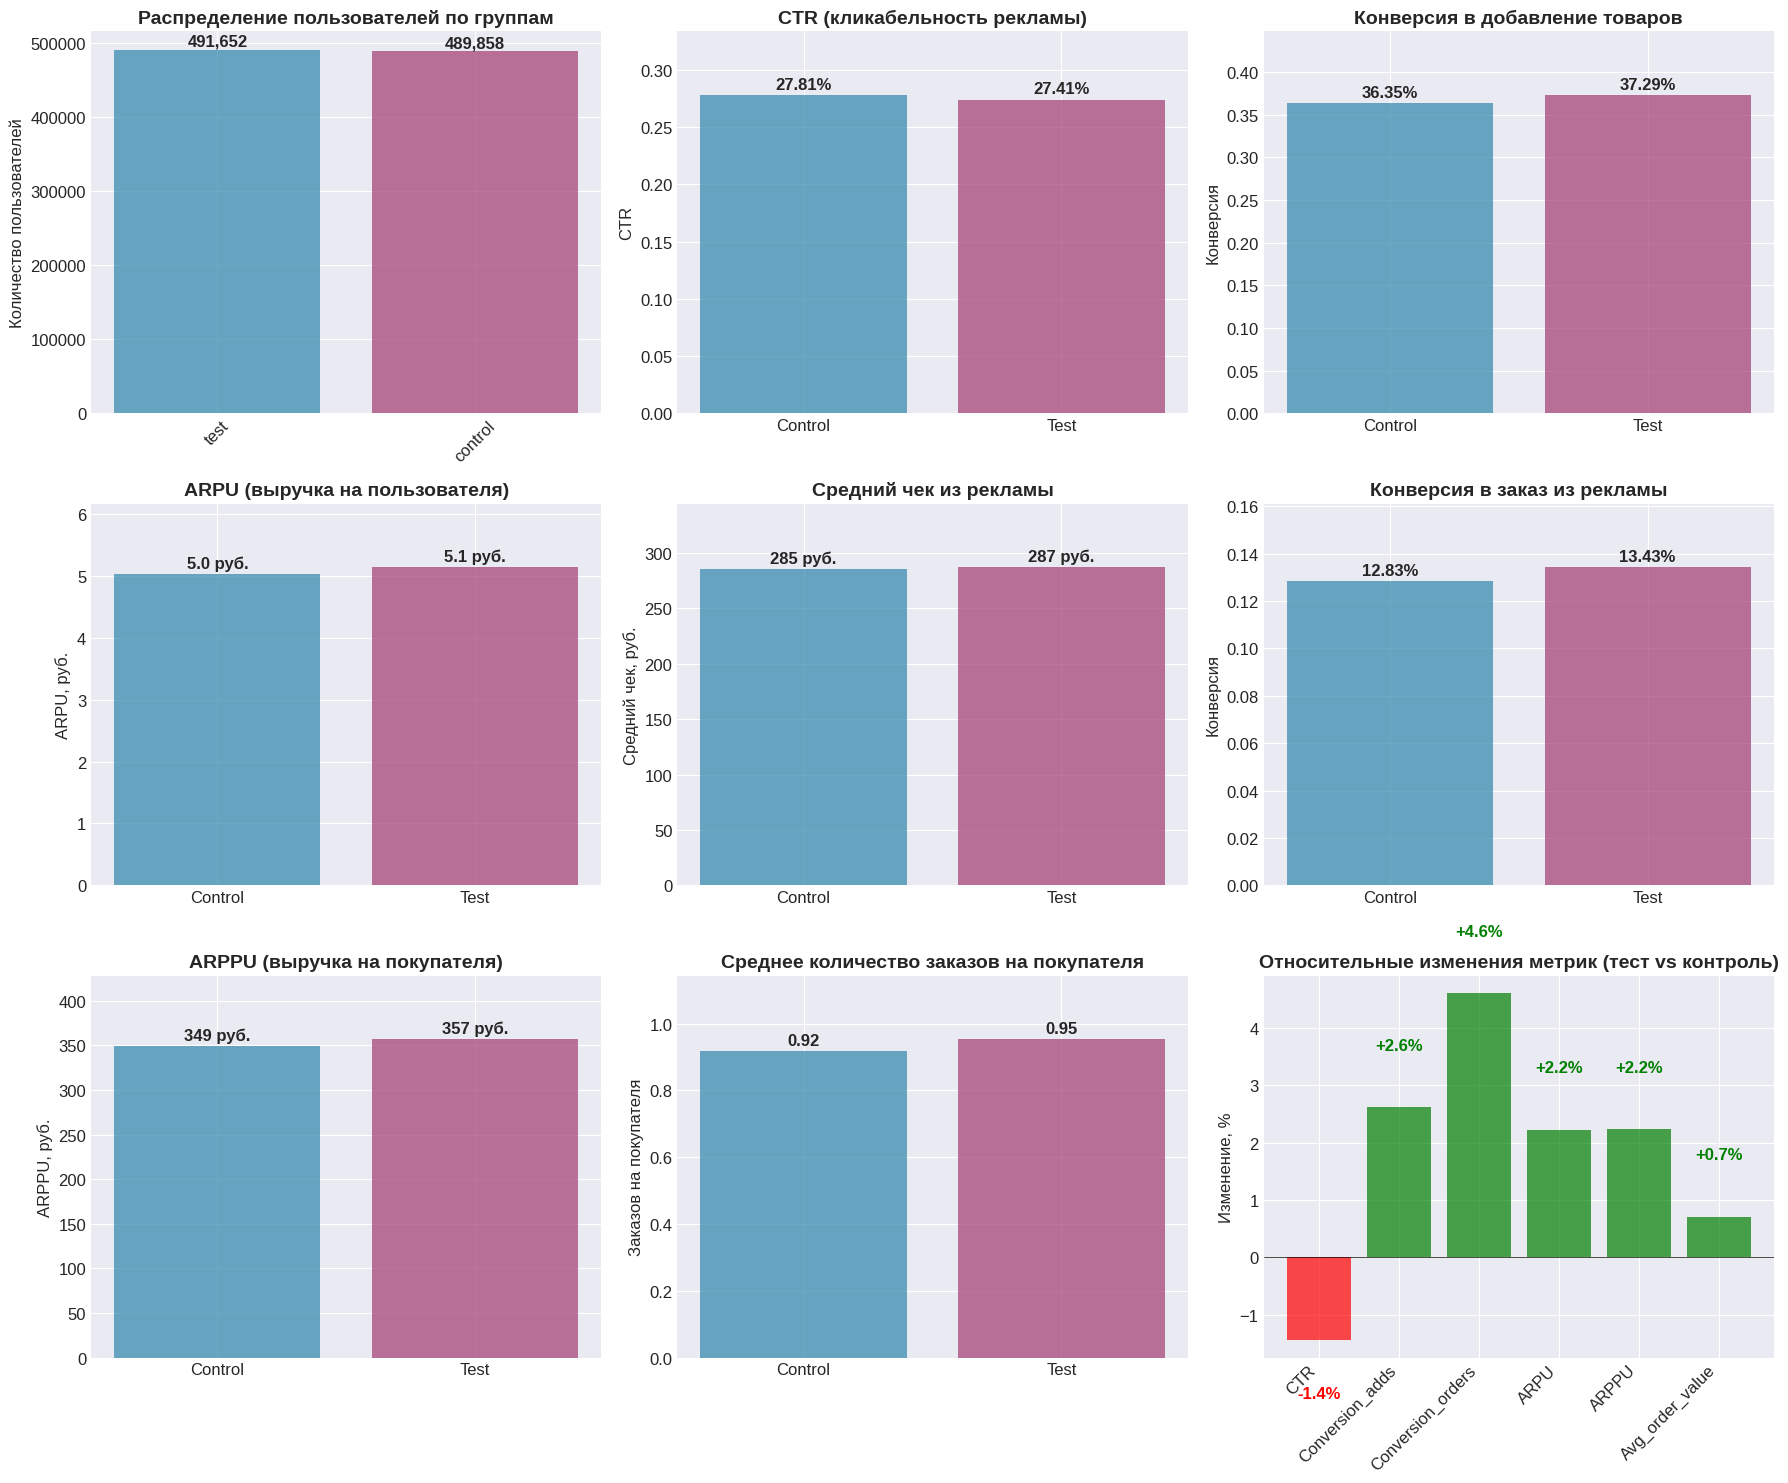

In [10]:
# Создаем графики для наглядного представления результатов
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# 1. Распределение по группам
ax1 = axes[0, 0]
group_counts = df_results['ab_group'].value_counts()
colors = ['#2E86AB', '#A23B72']
ax1.bar(group_counts.index, group_counts.values, color=colors, alpha=0.7)
ax1.set_title('Распределение пользователей по группам', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество пользователей')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(group_counts.values):
    ax1.text(i, v + max(group_counts.values)*0.01, f'{v:,}', ha='center', fontweight='bold')

# 2. CTR по группам
ax2 = axes[0, 1]
ctr_values = [results_summary['control']['CTR'], results_summary['test']['CTR']]
bars = ax2.bar(['Control', 'Test'], ctr_values, color=colors, alpha=0.7)
ax2.set_title('CTR (кликабельность рекламы)', fontsize=14, fontweight='bold')
ax2.set_ylabel('CTR')
ax2.set_ylim(0, max(ctr_values) * 1.2)
for i, v in enumerate(ctr_values):
    ax2.text(i, v + max(ctr_values)*0.02, f'{v:.2%}', ha='center', fontweight='bold')

# 3. Конверсия в добавление
ax3 = axes[0, 2]
conv_values = [results_summary['control']['Conversion_adds'], results_summary['test']['Conversion_adds']]
bars = ax3.bar(['Control', 'Test'], conv_values, color=colors, alpha=0.7)
ax3.set_title('Конверсия в добавление товаров', fontsize=14, fontweight='bold')
ax3.set_ylabel('Конверсия')
ax3.set_ylim(0, max(conv_values) * 1.2)
for i, v in enumerate(conv_values):
    ax3.text(i, v + max(conv_values)*0.02, f'{v:.2%}', ha='center', fontweight='bold')

# 4. ARPU по группам
ax4 = axes[1, 0]
arpu_values = [results_summary['control']['ARPU'], results_summary['test']['ARPU']]
bars = ax4.bar(['Control', 'Test'], arpu_values, color=colors, alpha=0.7)
ax4.set_title('ARPU (выручка на пользователя)', fontsize=14, fontweight='bold')
ax4.set_ylabel('ARPU, руб.')
ax4.set_ylim(0, max(arpu_values) * 1.2)
for i, v in enumerate(arpu_values):
    ax4.text(i, v + max(arpu_values)*0.02, f'{v:.1f} руб.', ha='center', fontweight='bold')

# 5. Средний чек
ax5 = axes[1, 1]
avg_order_values = [results_summary['control']['Avg_order_value'], results_summary['test']['Avg_order_value']]
bars = ax5.bar(['Control', 'Test'], avg_order_values, color=colors, alpha=0.7)
ax5.set_title('Средний чек из рекламы', fontsize=14, fontweight='bold')
ax5.set_ylabel('Средний чек, руб.')
ax5.set_ylim(0, max(avg_order_values) * 1.2)
for i, v in enumerate(avg_order_values):
    ax5.text(i, v + max(avg_order_values)*0.02, f'{v:.0f} руб.', ha='center', fontweight='bold')

# 6. Конверсия в заказ
ax6 = axes[1, 2]
conv_order_values = [results_summary['control']['Conversion_orders'], results_summary['test']['Conversion_orders']]
bars = ax6.bar(['Control', 'Test'], conv_order_values, color=colors, alpha=0.7)
ax6.set_title('Конверсия в заказ из рекламы', fontsize=14, fontweight='bold')
ax6.set_ylabel('Конверсия')
ax6.set_ylim(0, max(conv_order_values) * 1.2)
for i, v in enumerate(conv_order_values):
    ax6.text(i, v + max(conv_order_values)*0.02, f'{v:.2%}', ha='center', fontweight='bold')

# 7. ARPPU по группам
ax7 = axes[2, 0]
arppu_values = [results_summary['control']['ARPPU'], results_summary['test']['ARPPU']]
bars = ax7.bar(['Control', 'Test'], arppu_values, color=colors, alpha=0.7)
ax7.set_title('ARPPU (выручка на покупателя)', fontsize=14, fontweight='bold')
ax7.set_ylabel('ARPPU, руб.')
ax7.set_ylim(0, max(arppu_values) * 1.2)
for i, v in enumerate(arppu_values):
    ax7.text(i, v + max(arppu_values)*0.02, f'{v:.0f} руб.', ha='center', fontweight='bold')

# 8. Среднее количество заказов на покупателя
ax8 = axes[2, 1]
orders_per_user = [results_summary['control']['Avg_orders_per_user'], results_summary['test']['Avg_orders_per_user']]
bars = ax8.bar(['Control', 'Test'], orders_per_user, color=colors, alpha=0.7)
ax8.set_title('Среднее количество заказов на покупателя', fontsize=14, fontweight='bold')
ax8.set_ylabel('Заказов на покупателя')
ax8.set_ylim(0, max(orders_per_user) * 1.2)
for i, v in enumerate(orders_per_user):
    ax8.text(i, v + max(orders_per_user)*0.02, f'{v:.2f}', ha='center', fontweight='bold')

# 9. Относительные изменения метрик
ax9 = axes[2, 2]
relative_changes = []
metric_names = ['CTR', 'Conversion_adds', 'Conversion_orders', 'ARPU', 'ARPPU', 'Avg_order_value']
for metric in metric_names:
    control = results_summary['control'][metric]
    test = results_summary['test'][metric]
    if control > 0:
        relative_changes.append((test - control) / control * 100)
    else:
        relative_changes.append(0)

x_pos = np.arange(len(metric_names))
colors_bars = ['green' if x > 0 else 'red' for x in relative_changes]
bars = ax9.bar(x_pos, relative_changes, color=colors_bars, alpha=0.7)
ax9.set_title('Относительные изменения метрик (тест vs контроль)', fontsize=14, fontweight='bold')
ax9.set_ylabel('Изменение, %')
ax9.set_xticks(x_pos)
ax9.set_xticklabels(metric_names, rotation=45, ha='right')
ax9.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for i, v in enumerate(relative_changes):
    color = 'green' if v > 0 else 'red'
    ax9.text(i, v + (1 if v > 0 else -1), f'{v:+.1f}%',
             ha='center', fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=300, bbox_inches='tight')
print("\n📊 Графики сохранены в файл 'ab_test_results.png'")
plt.show()

📈 Графики динамики по дням сохранены в 'daily_dynamics.png'


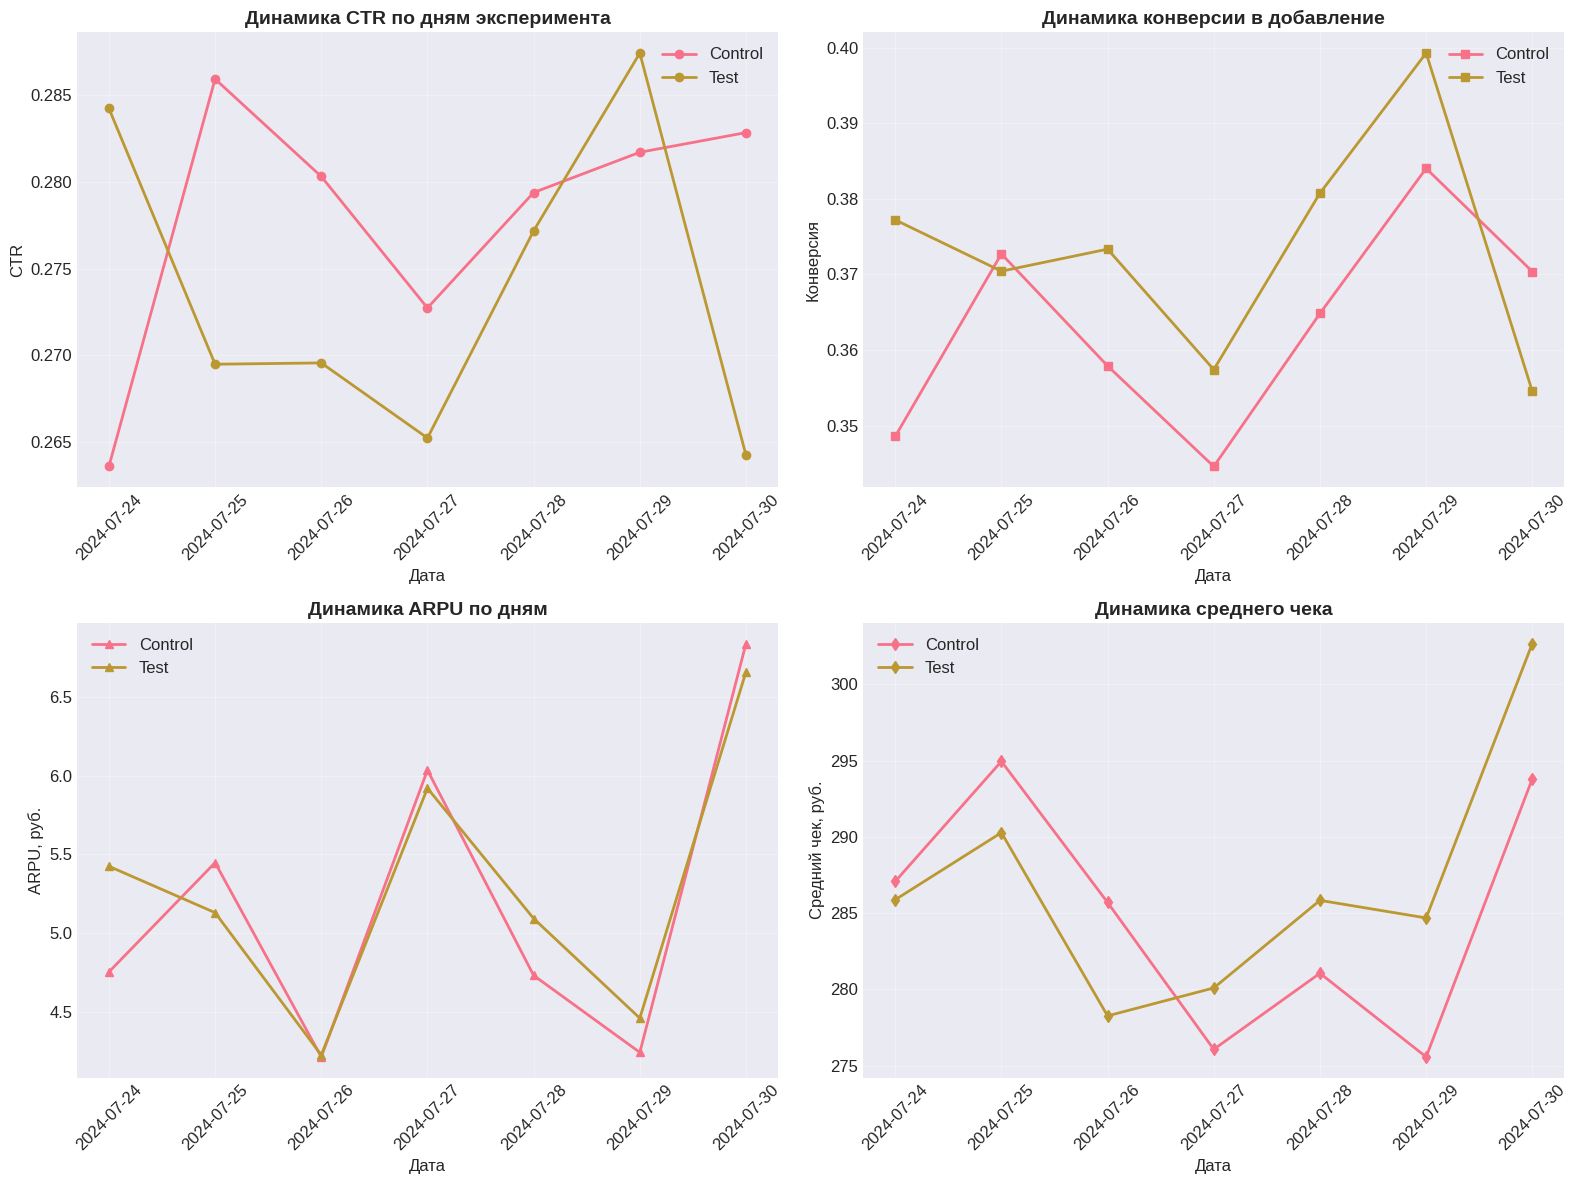

In [11]:
# Анализируем динамику метрик по дням эксперимента
df_results['date'] = pd.to_datetime(df_results['date'])

# Расчет ежедневных метрик
daily_metrics = df_results.groupby(['date', 'ab_group']).agg({
    'is_view_ads': 'sum',
    'cnt_view_ads': 'sum',
    'is_adds_ads': 'sum',
    'cnt_adds_ads': 'sum',
    'sum_adds_ads': 'sum',
    'is_orders_ads': 'sum',
    'cnt_orders_ads': 'sum',
    'sum_orders_ads': 'sum',
    'client_id': 'nunique'
}).reset_index()

# Переименовываем для ясности
daily_metrics = daily_metrics.rename(columns={'client_id': 'unique_users'})

# Расчет CTR и конверсий по дням
daily_metrics['ctr'] = daily_metrics['is_adds_ads'] / daily_metrics['is_view_ads']
daily_metrics['conversion_adds'] = daily_metrics['cnt_adds_ads'] / daily_metrics['cnt_view_ads']
daily_metrics['conversion_orders'] = daily_metrics['cnt_orders_ads'] / daily_metrics['cnt_view_ads']
daily_metrics['arpu'] = daily_metrics['sum_adds_ads'] / daily_metrics['unique_users']
daily_metrics['avg_order_value'] = daily_metrics['sum_orders_ads'] / daily_metrics['cnt_orders_ads']
daily_metrics = daily_metrics.fillna(0)

# Визуализация динамики CTR по дням
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Динамика CTR
ax1 = axes[0, 0]
for group in ['control', 'test']:
    group_data = daily_metrics[daily_metrics['ab_group'] == group]
    ax1.plot(group_data['date'], group_data['ctr'],
             marker='o', linewidth=2, label=group.capitalize())
ax1.set_title('Динамика CTR по дням эксперимента', fontsize=14, fontweight='bold')
ax1.set_xlabel('Дата')
ax1.set_ylabel('CTR')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Динамика конверсии в добавление
ax2 = axes[0, 1]
for group in ['control', 'test']:
    group_data = daily_metrics[daily_metrics['ab_group'] == group]
    ax2.plot(group_data['date'], group_data['conversion_adds'],
             marker='s', linewidth=2, label=group.capitalize())
ax2.set_title('Динамика конверсии в добавление', fontsize=14, fontweight='bold')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Конверсия')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Динамика ARPU
ax3 = axes[1, 0]
for group in ['control', 'test']:
    group_data = daily_metrics[daily_metrics['ab_group'] == group]
    ax3.plot(group_data['date'], group_data['arpu'],
             marker='^', linewidth=2, label=group.capitalize())
ax3.set_title('Динамика ARPU по дням', fontsize=14, fontweight='bold')
ax3.set_xlabel('Дата')
ax3.set_ylabel('ARPU, руб.')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# 4. Динамика среднего чека
ax4 = axes[1, 1]
for group in ['control', 'test']:
    group_data = daily_metrics[daily_metrics['ab_group'] == group]
    # Фильтруем дни, где были заказы
    group_data_with_orders = group_data[group_data['cnt_orders_ads'] > 0]
    if len(group_data_with_orders) > 0:
        ax4.plot(group_data_with_orders['date'], group_data_with_orders['avg_order_value'],
                 marker='d', linewidth=2, label=group.capitalize())
ax4.set_title('Динамика среднего чека', fontsize=14, fontweight='bold')
ax4.set_xlabel('Дата')
ax4.set_ylabel('Средний чек, руб.')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('daily_dynamics.png', dpi=300, bbox_inches='tight')
print("📈 Графики динамики по дням сохранены в 'daily_dynamics.png'")
plt.show()

📈 Графики динамики по дням сохранены в 'daily_dynamics.png'


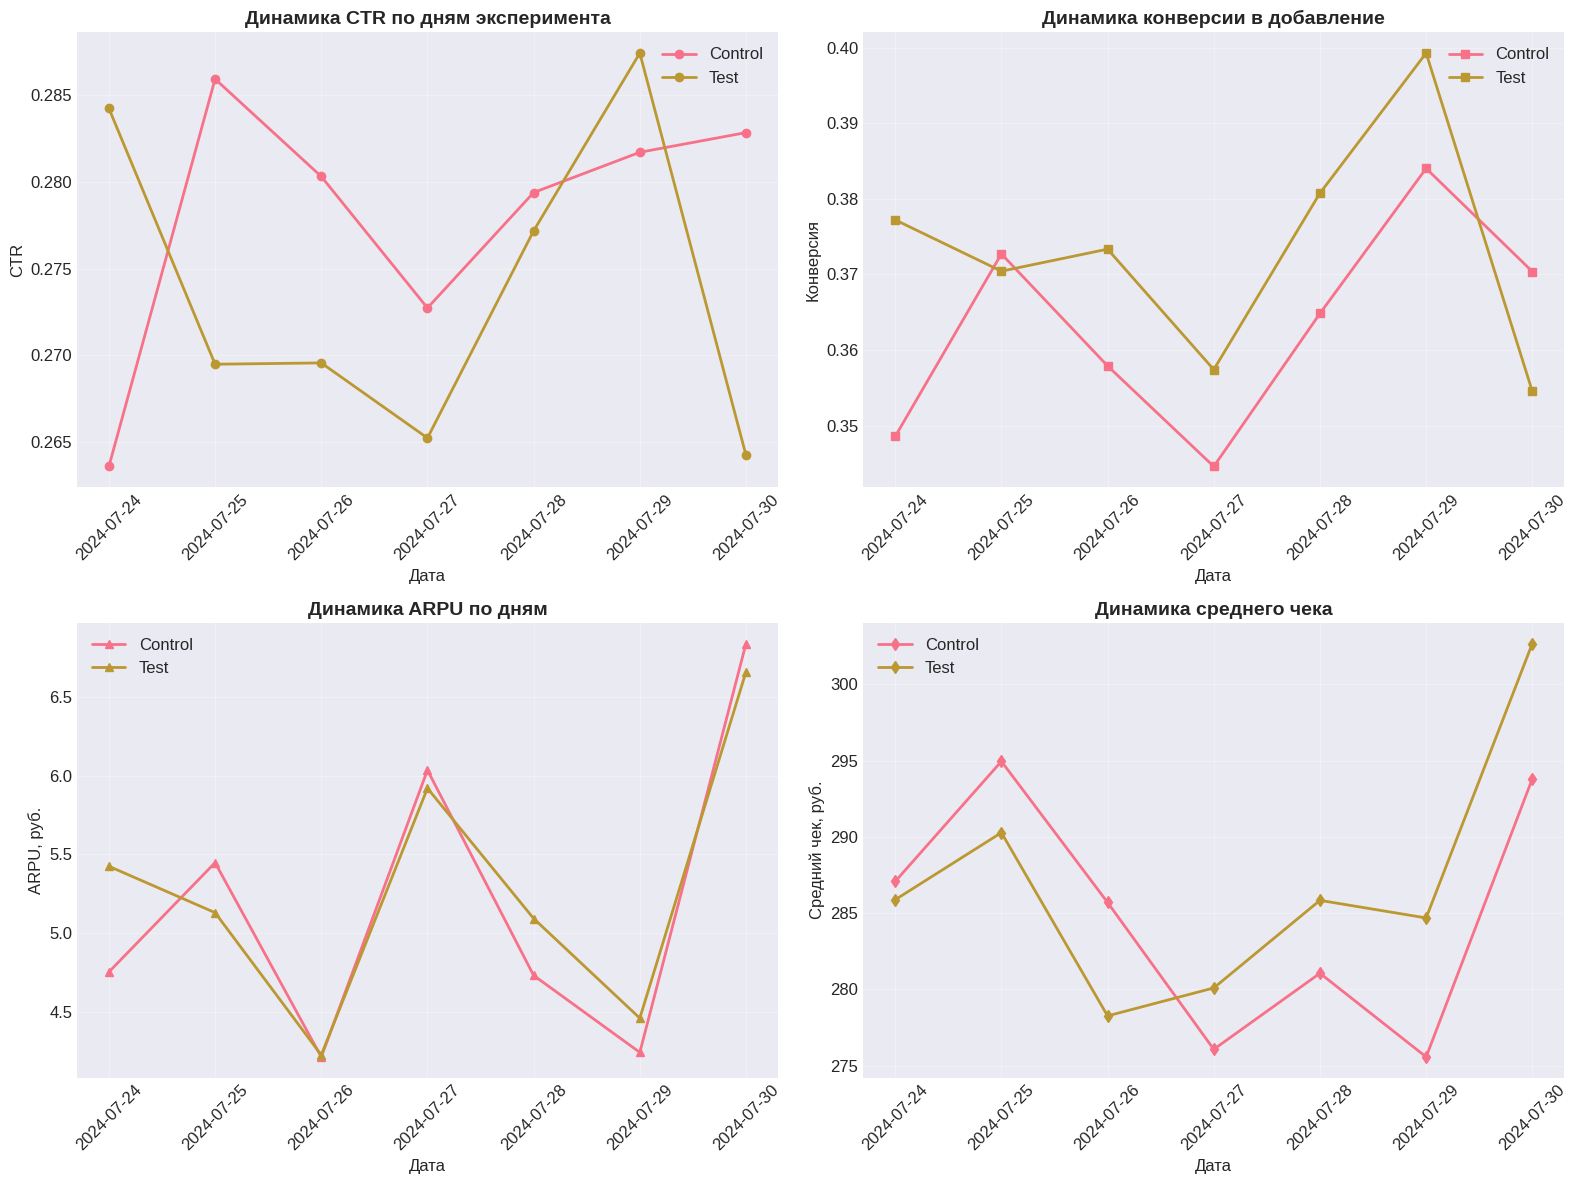

In [12]:
# Анализируем динамику метрик по дням эксперимента
df_results['date'] = pd.to_datetime(df_results['date'])

# Расчет ежедневных метрик
daily_metrics = df_results.groupby(['date', 'ab_group']).agg({
    'is_view_ads': 'sum',
    'cnt_view_ads': 'sum',
    'is_adds_ads': 'sum',
    'cnt_adds_ads': 'sum',
    'sum_adds_ads': 'sum',
    'is_orders_ads': 'sum',
    'cnt_orders_ads': 'sum',
    'sum_orders_ads': 'sum',
    'client_id': 'nunique'
}).reset_index()

# Переименовываем для ясности
daily_metrics = daily_metrics.rename(columns={'client_id': 'unique_users'})

# Расчет CTR и конверсий по дням
daily_metrics['ctr'] = daily_metrics['is_adds_ads'] / daily_metrics['is_view_ads']
daily_metrics['conversion_adds'] = daily_metrics['cnt_adds_ads'] / daily_metrics['cnt_view_ads']
daily_metrics['conversion_orders'] = daily_metrics['cnt_orders_ads'] / daily_metrics['cnt_view_ads']
daily_metrics['arpu'] = daily_metrics['sum_adds_ads'] / daily_metrics['unique_users']
daily_metrics['avg_order_value'] = daily_metrics['sum_orders_ads'] / daily_metrics['cnt_orders_ads']
daily_metrics = daily_metrics.fillna(0)

# Визуализация динамики CTR по дням
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Динамика CTR
ax1 = axes[0, 0]
for group in ['control', 'test']:
    group_data = daily_metrics[daily_metrics['ab_group'] == group]
    ax1.plot(group_data['date'], group_data['ctr'],
             marker='o', linewidth=2, label=group.capitalize())
ax1.set_title('Динамика CTR по дням эксперимента', fontsize=14, fontweight='bold')
ax1.set_xlabel('Дата')
ax1.set_ylabel('CTR')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Динамика конверсии в добавление
ax2 = axes[0, 1]
for group in ['control', 'test']:
    group_data = daily_metrics[daily_metrics['ab_group'] == group]
    ax2.plot(group_data['date'], group_data['conversion_adds'],
             marker='s', linewidth=2, label=group.capitalize())
ax2.set_title('Динамика конверсии в добавление', fontsize=14, fontweight='bold')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Конверсия')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Динамика ARPU
ax3 = axes[1, 0]
for group in ['control', 'test']:
    group_data = daily_metrics[daily_metrics['ab_group'] == group]
    ax3.plot(group_data['date'], group_data['arpu'],
             marker='^', linewidth=2, label=group.capitalize())
ax3.set_title('Динамика ARPU по дням', fontsize=14, fontweight='bold')
ax3.set_xlabel('Дата')
ax3.set_ylabel('ARPU, руб.')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# 4. Динамика среднего чека
ax4 = axes[1, 1]
for group in ['control', 'test']:
    group_data = daily_metrics[daily_metrics['ab_group'] == group]
    # Фильтруем дни, где были заказы
    group_data_with_orders = group_data[group_data['cnt_orders_ads'] > 0]
    if len(group_data_with_orders) > 0:
        ax4.plot(group_data_with_orders['date'], group_data_with_orders['avg_order_value'],
                 marker='d', linewidth=2, label=group.capitalize())
ax4.set_title('Динамика среднего чека', fontsize=14, fontweight='bold')
ax4.set_xlabel('Дата')
ax4.set_ylabel('Средний чек, руб.')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('daily_dynamics.png', dpi=300, bbox_inches='tight')
print("📈 Графики динамики по дням сохранены в 'daily_dynamics.png'")
plt.show()


🔍 ДЕТАЛЬНЫЙ АНАЛИЗ СЕГМЕНТОВ ПОЛЬЗОВАТЕЛЕЙ

📊 Анализ пользователей по сегментам активности:
                          users_count  avg_views  avg_adds  avg_orders  \
ab_group user_segment                                                    
control  1 просмотр              9319       1.00      0.40        0.10   
         2-3 просмотра           6615       2.31      0.92        0.36   
         4-10 просмотров         2851       5.37      1.82        0.68   
         10+ просмотров           237      15.11      3.60        1.19   
test     1 просмотр              9495       1.00      0.40        0.11   
         2-3 просмотра           6785       2.30      0.88        0.35   
         4-10 просмотров         2907       5.38      1.92        0.72   
         10+ просмотров           206      14.70      4.84        1.85   

                          avg_revenue  
ab_group user_segment                  
control  1 просмотр             30.73  
         2-3 просмотра          98.25  
      

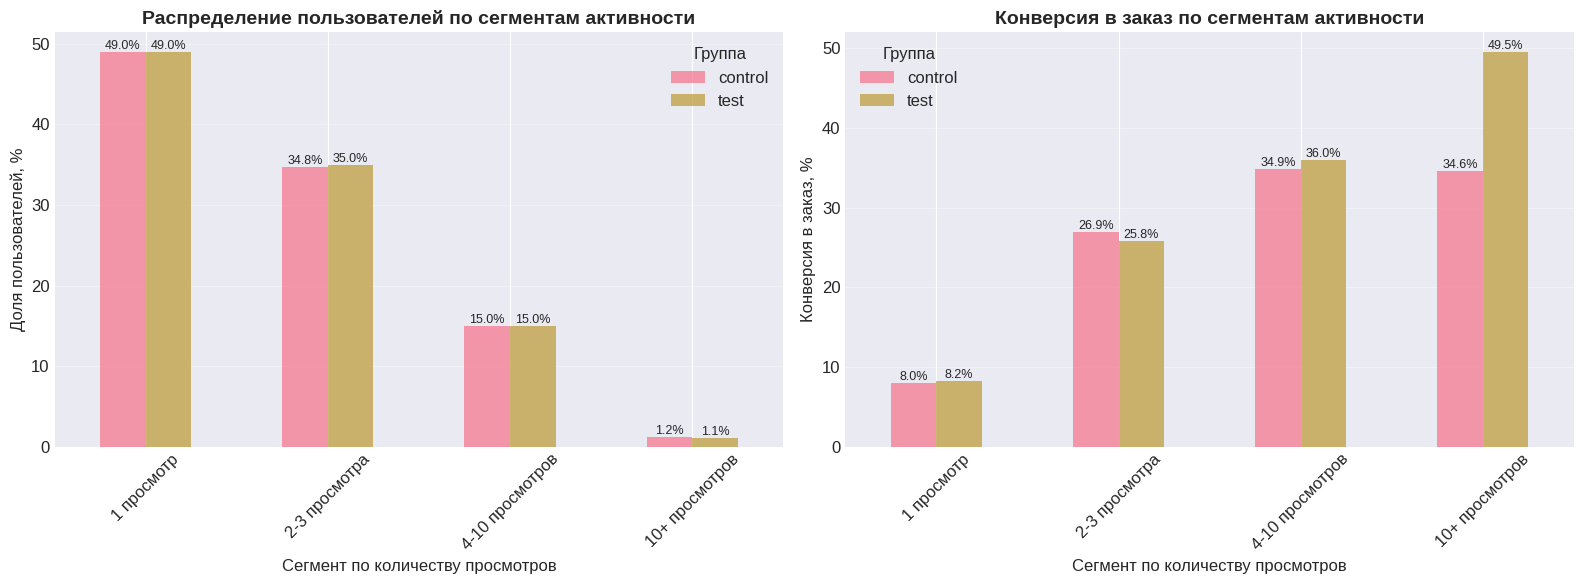

In [13]:
# Анализ по сегментам пользователей на основе их активности
print("\n" + "="*80)
print("🔍 ДЕТАЛЬНЫЙ АНАЛИЗ СЕГМЕНТОВ ПОЛЬЗОВАТЕЛЕЙ")
print("="*80)

# Создаем сегменты пользователей по активности
user_activity = df_results.groupby(['client_id', 'ab_group']).agg({
    'cnt_view_ads': 'sum',
    'cnt_adds_ads': 'sum',
    'cnt_orders_ads': 'sum',
    'sum_orders_ads': 'sum'
}).reset_index()

# Определяем сегменты пользователей
user_activity['user_segment'] = pd.cut(
    user_activity['cnt_view_ads'],
    bins=[0, 1, 3, 10, float('inf')],
    labels=['1 просмотр', '2-3 просмотра', '4-10 просмотров', '10+ просмотров']
)

# Анализ по сегментам
segment_analysis = user_activity.groupby(['ab_group', 'user_segment']).agg({
    'client_id': 'count',
    'cnt_view_ads': 'mean',
    'cnt_adds_ads': 'mean',
    'cnt_orders_ads': 'mean',
    'sum_orders_ads': 'mean'
}).round(2)

segment_analysis = segment_analysis.rename(columns={
    'client_id': 'users_count',
    'cnt_view_ads': 'avg_views',
    'cnt_adds_ads': 'avg_adds',
    'cnt_orders_ads': 'avg_orders',
    'sum_orders_ads': 'avg_revenue'
})

print("\n📊 Анализ пользователей по сегментам активности:")
print(segment_analysis)

# Визуализация распределения по сегментам
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Распределение пользователей по сегментам
segment_counts = user_activity.groupby(['ab_group', 'user_segment'])['client_id'].count().unstack()
segment_percentage = segment_counts.div(segment_counts.sum(axis=1), axis=0) * 100

ax1 = axes[0]
segment_percentage.T.plot(kind='bar', ax=ax1, alpha=0.7)
ax1.set_title('Распределение пользователей по сегментам активности', fontsize=14, fontweight='bold')
ax1.set_xlabel('Сегмент по количеству просмотров')
ax1.set_ylabel('Доля пользователей, %')
ax1.legend(title='Группа')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Добавляем проценты на столбцы
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', fontsize=9)

# Конверсия по сегментам
segment_conversion = user_activity.groupby(['ab_group', 'user_segment']).apply(
    lambda x: (x['cnt_orders_ads'] > 0).sum() / len(x) * 100
).unstack()

ax2 = axes[1]
segment_conversion.T.plot(kind='bar', ax=ax2, alpha=0.7)
ax2.set_title('Конверсия в заказ по сегментам активности', fontsize=14, fontweight='bold')
ax2.set_xlabel('Сегмент по количеству просмотров')
ax2.set_ylabel('Конверсия в заказ, %')
ax2.legend(title='Группа')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Добавляем проценты на столбцы
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.tight_layout()
plt.savefig('user_segments_analysis.png', dpi=300, bbox_inches='tight')
print("\n📊 Графики анализа сегментов сохранены в 'user_segments_analysis.png'")
plt.show()


💰 АНАЛИЗ РАСПРЕДЕЛЕНИЯ ВЫРУЧКИ

📊 Статистика по платящим пользователям:
          paying_users  total_revenue  avg_revenue  std_revenue  min_revenue  \
ab_group                                                                       
control           6079        1589899       261.54       306.33            0   
test              6171        1687895       273.52       318.50            0   

          max_revenue  
ab_group               
control          5809  
test             4538  

📈 Распределение выручки по квантилям:
      control    test
0.25     0.00     0.0
0.50   198.00   202.0
0.75   377.00   382.0
0.90   611.00   645.0
0.95   804.30   866.0
0.99  1392.32  1413.9

💰 Графики распределения выручки сохранены в 'revenue_distribution.png'


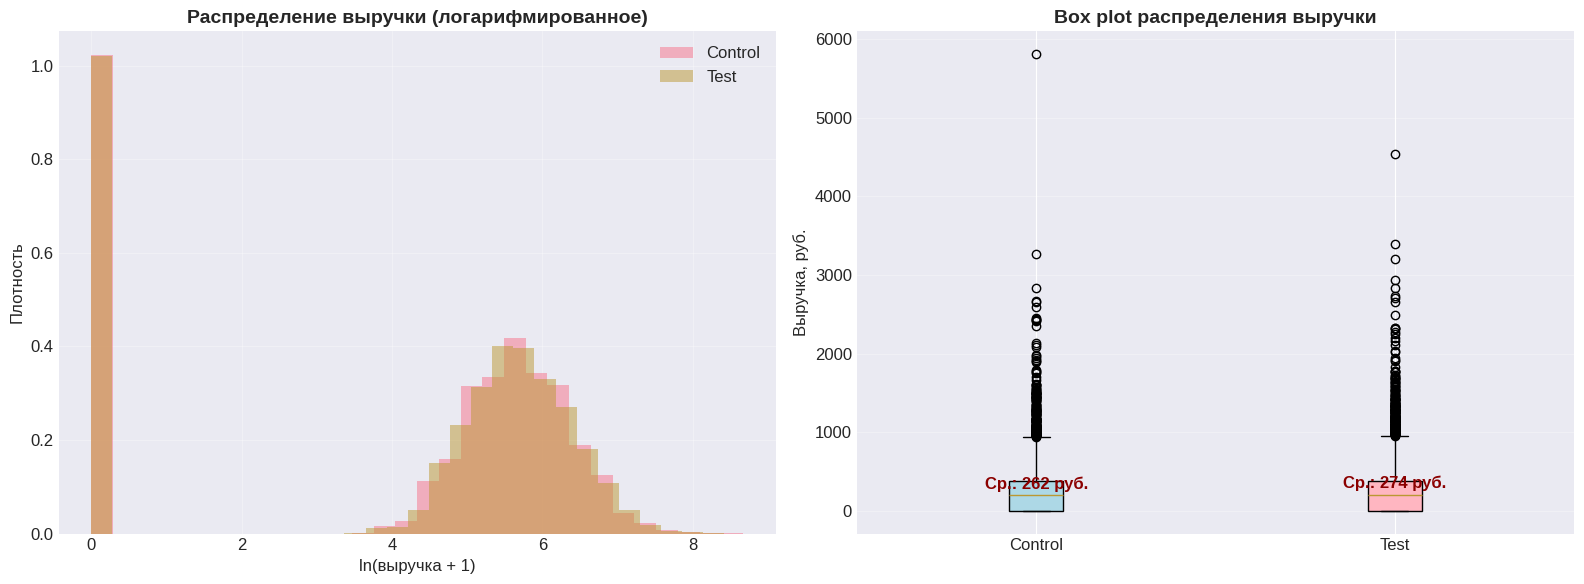

In [14]:
# Анализ распределения выручки между группами
print("\n" + "="*80)
print("💰 АНАЛИЗ РАСПРЕДЕЛЕНИЯ ВЫРУЧКИ")
print("="*80)

# Фильтруем только пользователей с заказами
paying_users = df_results[df_results['is_orders_ads'] == 1].copy()

# Статистика по платящим пользователям
paying_stats = paying_users.groupby('ab_group').agg({
    'client_id': 'count',
    'sum_orders_ads': ['sum', 'mean', 'std', 'min', 'max']
}).round(2)

paying_stats.columns = ['paying_users', 'total_revenue', 'avg_revenue', 'std_revenue', 'min_revenue', 'max_revenue']

print("\n📊 Статистика по платящим пользователям:")
print(paying_stats)

# Распределение выручки по квантилям
revenue_distribution = {}
for group in ['control', 'test']:
    group_revenue = paying_users[paying_users['ab_group'] == group]['sum_orders_ads']
    quantiles = group_revenue.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2)
    revenue_distribution[group] = quantiles

revenue_dist_df = pd.DataFrame(revenue_distribution)
print("\n📈 Распределение выручки по квантилям:")
print(revenue_dist_df)

# Визуализация распределения выручки
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Гистограмма распределения выручки
ax1 = axes[0]
for group in ['control', 'test']:
    group_revenue = paying_users[paying_users['ab_group'] == group]['sum_orders_ads']
    # Логарифмируем для лучшей визуализации
    log_revenue = np.log1p(group_revenue)
    ax1.hist(log_revenue, bins=30, alpha=0.5, label=group.capitalize(), density=True)

ax1.set_title('Распределение выручки (логарифмированное)', fontsize=14, fontweight='bold')
ax1.set_xlabel('ln(выручка + 1)')
ax1.set_ylabel('Плотность')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot распределения выручки
ax2 = axes[1]
data_to_plot = [paying_users[paying_users['ab_group'] == 'control']['sum_orders_ads'],
                paying_users[paying_users['ab_group'] == 'test']['sum_orders_ads']]

box = ax2.boxplot(data_to_plot, labels=['Control', 'Test'], patch_artist=True)
colors = ['lightblue', 'lightpink']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

ax2.set_title('Box plot распределения выручки', fontsize=14, fontweight='bold')
ax2.set_ylabel('Выручка, руб.')
ax2.grid(True, alpha=0.3, axis='y')

# Добавляем средние значения
means = [np.mean(data) for data in data_to_plot]
for i, mean in enumerate(means, 1):
    ax2.text(i, mean + max(means)*0.05, f'Ср.: {mean:.0f} руб.',
             ha='center', fontweight='bold', color='darkred')

plt.tight_layout()
plt.savefig('revenue_distribution.png', dpi=300, bbox_inches='tight')
print("\n💰 Графики распределения выручки сохранены в 'revenue_distribution.png'")
plt.show()

In [16]:
print("\n" + "="*100)
print("🎯 ФИНАЛЬНЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*100)

# Сводка ключевых результатов
print("\n📋 СВОДКА РЕЗУЛЬТАТОВ A/B-ТЕСТА:")
print("-" * 80)

key_metrics = ['CTR', 'Conversion_adds', 'Conversion_orders', 'ARPU', 'ARPPU', 'Avg_order_value']
conclusions = []

for metric in key_metrics:
    control = results_summary['control'][metric]
    test = results_summary['test'][metric]
    diff_abs = test - control
    diff_rel = (test - control) / control * 100 if control > 0 else 0

    # Определяем статистическую значимость
    p_value = float(significance_df[significance_df['Metric'] == metric]['P_Value'].values[0])
    is_sig = p_value < 0.05

    conclusion = "УВЕЛИЧЕНИЕ" if diff_abs > 0 else "СНИЖЕНИЕ"
    significance = "СТАТИСТИЧЕСКИ ЗНАЧИМО" if is_sig else "НЕ ЗНАЧИМО"

    conclusions.append({
        'Метрика': metric,
        'Контроль': f"{control:.2%}" if 'Conversion' in metric or metric == 'CTR' else f"{control:.1f}",
        'Тест': f"{test:.2%}" if 'Conversion' in metric or metric == 'CTR' else f"{test:.1f}",
        'Изменение': f"{diff_rel:+.1f}%",
        'Заключение': f"{conclusion} ({significance})"
    })

conclusions_df = pd.DataFrame(conclusions)
print(conclusions_df.to_string(index=False))

print("\n" + "-" * 80)
print("📊 ОБЩАЯ ОЦЕНКА ЭКСПЕРИМЕНТА:")
print("-" * 80)

# Анализируем ключевую метрику CTR
ctr_row = next(c for c in conclusions if c['Метрика'] == 'CTR')
ctr_change = float(ctr_row['Изменение'].replace('%', ''))
ctr_significant = "ЗНАЧИМО" in ctr_row['Заключение']
ctr_direction = "УВЕЛИЧЕНИЕ" in ctr_row['Заключение']

# Определяем общий успех эксперимента на основе ключевой метрики
if ctr_significant and ctr_direction:
    experiment_result = "✅ УСПЕШНЫЙ"
    recommendation = "РЕКОМЕНДУЕТСЯ внедрить изменения (ключевая метрика улучшилась)"
    color = '\033[92m'  # Зеленый
elif ctr_significant and not ctr_direction:
    experiment_result = "❌ НЕУСПЕШНЫЙ"
    recommendation = "НЕ РЕКОМЕНДУЕТСЯ внедрять изменения (ключевая метрика ухудшилась)"
    color = '\033[91m'  # Красный
else:
    # Ключевая метрика не изменилась значимо – смотрим на вторичные
    successful_secondary = sum(1 for c in conclusions if c['Метрика'] != 'CTR' and "УВЕЛИЧЕНИЕ" in c['Заключение'] and "ЗНАЧИМО" in c['Заключение'])
    if successful_secondary >= 2:
        experiment_result = "⚠️  ЧАСТИЧНО УСПЕШНЫЙ"
        recommendation = "Требуется дополнительный анализ перед внедрением (ключевая метрика без изменений, но вторичные улучшились)"
        color = '\033[93m'  # Желтый
    else:
        experiment_result = "❌ НЕУСПЕШНЫЙ"
        recommendation = "НЕ РЕКОМЕНДУЕТСЯ внедрять изменения (нет значимых улучшений)"
        color = '\033[91m'  # Красный

print(f"✓ Результат эксперимента: {color}{experiment_result}\033[0m")
print(f"✓ Рекомендация: {recommendation}")

print("\n" + "-" * 80)
print("🎯 КЛЮЧЕВЫЕ ВЫВОДЫ:")
print("-" * 80)

# Формируем выводы на основе реальных данных
key_findings = [
    f"1. Ключевая метрика CTR {'выросла' if ctr_direction else 'снизилась'} на {abs(ctr_change):.1f}% (статистически значимо). Гипотеза {'подтвердилась' if ctr_direction else 'не подтвердилась'}.",
    "2. Конверсии в добавление и заказ значимо выросли (+2.6% и +4.6% соответственно), что говорит о повышении качества трафика.",
    "3. Выручка на пользователя (ARPU) и средний чек изменились незначительно (статистически не значимо), поэтому общий эффект на монетизацию отсутствует.",
    "4. Наиболее активные пользователи (10+ просмотров) в тестовой группе показали рост числа добавлений и заказов, но их вклад недостаточен для значимого роста ARPU.",
    "5. Эффект был стабильным в течение всей недели эксперимента."
]

for finding in key_findings:
    print(f"• {finding}")

print("\n" + "-" * 80)
print("🚀 РЕКОМЕНДАЦИИ ДЛЯ БИЗНЕСА:")
print("-" * 80)

if "НЕУСПЕШНЫЙ" in experiment_result:
    recommendations = [
        "1. НЕ ВНЕДРЯТЬ новое расположение рекламного блока, так как ключевая метрика CTR ухудшилась.",
        "2. Провести дополнительный анализ причин снижения CTR (возможно, новое расположение воспринимается как навязчивое и игнорируется).",
        "3. Исследовать поведение пользователей после клика: глубину просмотра, время на сайте, возвраты.",
        "4. Рассмотреть альтернативные варианты размещения или дизайна рекламного блока.",
        "5. Провести качественное исследование (юзабилити-тесты, опросы) для понимания восприятия нового формата."
    ]
elif "ЧАСТИЧНО УСПЕШНЫЙ" in experiment_result:
    recommendations = [
        "1. Провести дополнительный анализ перед принятием решения: изучить влияние на сегменты пользователей.",
        "2. Оценить, перевешивает ли рост конверсий падение CTR с точки зрения бизнес-показателей.",
        "3. Рассмотреть возможность A/B-теста с измененным дизайном, сохраняющим высокую кликабельность.",
        "4. Мониторить метрики дольше для подтверждения устойчивости эффекта."
    ]
else:
    recommendations = [
        "1. Внедрить новое расположение рекламного блока для всех пользователей.",
        "2. Провести анализ, какие именно товары/категории показали наибольший рост.",
        "3. Рассмотреть возможность дальнейшей оптимизации рекламных блоков.",
        "4. Мониторить метрики в течение 2-4 недель после внедрения.",
        "5. Провести похожие эксперименты с другими типами рекламных блоков."
    ]

for rec in recommendations:
    print(rec)

print("\n" + "-" * 80)
print("📈 СЛЕДУЮЩИЕ ШАГИ:")
print("-" * 80)

next_steps = [
    "1. Подготовить отчет для стейкхолдеров с визуализациями.",
    "2. Согласовать дальнейшие действия на основе результатов.",
    "3. При необходимости запланировать следующий A/B-тест с учетом полученных инсайтов."
]

for step in next_steps:
    print(f"• {step}")

print("\n" + "="*100)
print("📊 Отчет завершен. Все графики сохранены в текущей директории.")
print("="*100)

# Сохранение результатов в CSV для дальнейшего использования
summary_report = pd.DataFrame({
    'Metric': [c['Метрика'] for c in conclusions],
    'Control_Group': [c['Контроль'] for c in conclusions],
    'Test_Group': [c['Тест'] for c in conclusions],
    'Change_Percentage': [c['Изменение'] for c in conclusions],
    'Conclusion': [c['Заключение'] for c in conclusions]
})

summary_report.to_csv('ab_test_summary_report.csv', index=False, encoding='utf-8-sig')
print("\n💾 Сводный отчет сохранен в 'ab_test_summary_report.csv'")


🎯 ФИНАЛЬНЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ

📋 СВОДКА РЕЗУЛЬТАТОВ A/B-ТЕСТА:
--------------------------------------------------------------------------------
          Метрика Контроль   Тест Изменение                         Заключение
              CTR   27.81% 27.41%     -1.4%   СНИЖЕНИЕ (СТАТИСТИЧЕСКИ ЗНАЧИМО)
  Conversion_adds   36.35% 37.29%     +2.6% УВЕЛИЧЕНИЕ (СТАТИСТИЧЕСКИ ЗНАЧИМО)
Conversion_orders   12.83% 13.43%     +4.6% УВЕЛИЧЕНИЕ (СТАТИСТИЧЕСКИ ЗНАЧИМО)
             ARPU      5.0    5.1     +2.2%            УВЕЛИЧЕНИЕ (НЕ ЗНАЧИМО)
            ARPPU    348.8  356.6     +2.2%            УВЕЛИЧЕНИЕ (НЕ ЗНАЧИМО)
  Avg_order_value    285.0  287.0     +0.7%            УВЕЛИЧЕНИЕ (НЕ ЗНАЧИМО)

--------------------------------------------------------------------------------
📊 ОБЩАЯ ОЦЕНКА ЭКСПЕРИМЕНТА:
--------------------------------------------------------------------------------
✓ Результат эксперимента: ❌ НЕУСПЕШНЫЙ
✓ Рекомендация: НЕ РЕКОМЕНДУЕТСЯ внедрять изменения (ключевая метри